<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_C/Exp_4_Decision_Tree_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT

In [ ]:
# Cell 1: Import Libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## Import Libraries

This section imports all the necessary libraries for this project.

- `numpy` for numerical operations, especially for handling arrays and mathematical functions.
- `pandas` for data manipulation and analysis, specifically for creating and working with DataFrames.
- `sklearn.datasets.load_iris` to load the Iris dataset, a commonly used dataset for classification.
- `sklearn.model_selection.train_test_split` to split the dataset into training and testing sets.
- `sklearn.tree.DecisionTreeClassifier` to build and train a Decision Tree model.
- `sklearn.tree.plot_tree` to visualize the trained Decision Tree.
- `sklearn.metrics.accuracy_score` to evaluate the performance of the classification model.
- `matplotlib.pyplot` for creating visualizations, specifically for plotting the decision trees and accuracy vs. alpha graph.

In [ ]:
# Cell 1: Import Libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## Load and Display Dataset Details

This section loads the Iris dataset and provides an initial look at its structure and content.

The Iris dataset is a classic benchmark dataset for classification. It contains 150 samples of iris flowers, with four features measured from each sample: sepal length, sepal width, petal length, and petal width. The dataset also includes the species of each flower (setosa, versicolor, or virginica).

- The code loads the dataset using `load_iris()`.
- The features (`X`) and target (`y`) are extracted.
- A pandas DataFrame is created for easier viewing and exploration, adding the species names for clarity.
- Basic information about the dataset, such as feature names, class names, the first few rows, and data types, is printed.

In [ ]:
# Cell 2: Load and Explore the Dataset
print("--- Loading and Describing the IRIS Dataset ---")
iris = load_iris()
X = iris.data
y = iris.target

# Create a pandas DataFrame for better visualization
iris_df = pd.DataFrame(data=X, columns=iris.feature_names)
iris_df['species_name'] = iris.target_names[y]

print("Dataset Features:", iris.feature_names)
print("\nDataset Classes:", iris.target_names)
print("\nFirst 5 rows of the dataset:")
print(iris_df.head())
print("\nDataset Information:")
iris_df.info()

## Split the dataset (70% train, 30% test)

This section prepares the data for training and evaluation by splitting it into separate sets for training and testing.

- The `train_test_split` function from scikit-learn is used to divide the feature data (`X`) and the target labels (`y`) into training and testing subsets.
- By convention, the data is typically split into a larger portion for training (e.g., 70%) and a smaller portion for testing (e.g., 30%).
- `test_size=0.3` specifies that 30% of the data will be allocated to the testing set.
- `random_state=42` ensures that the splitting process is reproducible. Using the same `random_state` value will always result in the same split of data.
- The shapes of the resulting training and testing sets are printed to confirm the split.

In [ ]:
# Cell 3: Split the dataset (70% train, 30% test)
print("--- Splitting dataset into 70% training and 30% testing sets ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

## Decision Tree with Entropy Criterion

This section focuses on building and evaluating a Decision Tree classifier using the **entropy** criterion.

A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It works by recursively partitioning the data based on the values of the input features, creating a tree-like structure of decisions.

The **criterion** parameter in a Decision Tree determines the function used to measure the quality of a split. The goal is to choose splits that maximize the information gain or minimize the impurity at each node.

**Entropy** is a measure of impurity or randomness in a set of data. In the context of Decision Trees, it quantifies the uncertainty or disorder of the class distribution at a node.

The formula for entropy for a set S is:

$ H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i) $

Where:
- $c$ is the number of classes.
- $p_i$ is the proportion of samples belonging to class $i$ in the set $S$.

A lower entropy value indicates a more pure node (samples mostly belong to one class), while a higher entropy value indicates a more impure node (samples are more evenly distributed across classes). The Decision Tree algorithm aims to find splits that result in the greatest reduction in entropy (maximum information gain).

- A `DecisionTreeClassifier` is initialized with `criterion='entropy'`.
- The model is trained on the training data (`X_train`, `y_train`).
- Predictions are made on the testing data (`X_test`).
- The accuracy of the model is calculated and printed.
- The depth of the trained tree is also printed.
- The decision tree is visualized to show the learned structure and splitting rules.

In [ ]:
# Cell 4: Train and Visualize with 'entropy' criterion
print("--- Training and Visualizing with 'entropy' criterion ---")
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)

# Performance Measures
y_pred_entropy = clf_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
depth_entropy = clf_entropy.get_depth()

print(f"Accuracy (entropy): {accuracy_entropy:.4f}")
print(f"Tree Depth (entropy): {depth_entropy}")

# Visualize the tree
plt.figure(figsize=(18, 12))
plot_tree(clf_entropy, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title("Decision Tree using Criterion: Entropy")
plt.show()

## Decision Tree with Gini Criterion

This section explores building and evaluating a Decision Tree classifier using the **Gini impurity** criterion.

Similar to entropy, **Gini impurity** is another measure of impurity used in Decision Trees. It measures the probability of incorrectly classifying a randomly chosen element in the dataset if it were randomly labeled according to the distribution of labels in the subset.

The formula for Gini impurity for a set S is:

$ Gini(S) = 1 - \sum_{i=1}^{c} p_i^2 $

Where:
- $c$ is the number of classes.
- $p_i$ is the proportion of samples belonging to class $i$ in the set $S$.

A lower Gini impurity value indicates a more pure node. The Decision Tree algorithm aims to find splits that minimize the Gini impurity at each node.

- A `DecisionTreeClassifier` is initialized with `criterion='gini'`.
- The model is trained on the training data (`X_train`, `y_train`).
- Predictions are made on the testing data (`X_test`).
- The accuracy of the model is calculated and printed.
- The depth of the trained tree is also printed.
- The decision tree is visualized to show the learned structure and splitting rules.

In [ ]:
# Cell 5: Training and Visualizing with 'gini' criterion
print("--- Training and Visualizing with 'gini' criterion ---")
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)

# Performance Measures
y_pred_gini = clf_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)
depth_gini = clf_gini.get_depth()

print(f"Accuracy (gini): {accuracy_gini:.4f}")
print(f"Tree Depth (gini): {depth_gini}")

# Visualize the tree
plt.figure(figsize=(18, 12))
plot_tree(clf_gini, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title("Decision Tree using Criterion: Gini")
plt.show()

## Comparison of Initial Models

This section provides a summary comparison of the Decision Tree models trained using the 'entropy' and 'gini' criteria without any pruning.

The comparison includes:

- **Accuracy:** The proportion of correctly classified instances on the test set. A higher accuracy indicates better performance.
- **Tree Depth:** The longest path from the root node to a leaf node. A deeper tree can potentially capture more complex relationships but is also more prone to overfitting.

By comparing these metrics, we can get an initial idea of which criterion performed better on this specific dataset and split.

In [ ]:
# Cell 6: Final Comparison of Initial Models
print("--- Final Comparison of Initial Models ---")
print(f"Entropy Model -> Accuracy: {accuracy_entropy:.4f}, Depth: {depth_entropy}")
print(f"Gini Model    -> Accuracy: {accuracy_gini:.4f}, Depth: {depth_gini}")

## Find the Optimal ccp_alpha for Post-Pruning

This section focuses on **Post-Pruning** a Decision Tree to prevent overfitting and improve its generalization performance on unseen data.

**Post-Pruning** involves building a full decision tree first and then removing (pruning) branches that do not contribute significantly to improving the model's performance on a validation set or by using a cost-complexity measure.

One common technique for post-pruning is **Cost Complexity Pruning**, also known as weakest link pruning. This method finds a sequence of progressively smaller trees by iteratively removing the weakest link, which is the node that, when pruned, results in the smallest increase in the total impurity relative to the number of leaves removed.

The parameter `ccp_alpha` (Cost Complexity Pruning Alpha) is a non-negative floating-point value used to control the amount of pruning. Higher values of `ccp_alpha` result in more aggressive pruning. The cost complexity measure for a tree T is defined as:

$ R_{\alpha}(T) = R(T) + \alpha |T| $

Where:
- $R(T)$ is the total impurity of the leaf nodes of the tree T (e.g., sum of Gini impurities or entropies of the leaves).
- $|T|$ is the number of leaf nodes in the tree T.
- $\alpha$ is the `ccp_alpha` parameter.

The goal of cost complexity pruning is to find the subtree that minimizes $R_{\alpha}(T)$. As $\alpha$ increases, the penalty for having more leaves increases, leading to smaller (more pruned) trees.

- The `cost_complexity_pruning_path()` method of the trained Decision Tree (here, the Gini tree is used) is used to calculate the `ccp_alphas` and corresponding impurities for different levels of pruning.
- A series of Decision Trees are trained, each with a different `ccp_alpha` value from the pruning path.
- The accuracy of each of these trees is evaluated on both the training and testing sets.
- The `ccp_alpha` value that yields the highest accuracy on the **testing set** is considered the optimal value. This is because the testing set provides an unbiased estimate of the model's performance on unseen data.
- The code plots the accuracy on the training and testing sets against the different `ccp_alpha` values to visualize the effect of pruning and identify the optimal alpha.

In [ ]:
# Cell 7: Find the optimal ccp_alpha for Post-Pruning
print("--- Finding the optimal ccp_alpha for Post-Pruning ---")
path = clf_gini.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# We exclude the maximum alpha as it prunes the tree to just a root node.
ccp_alphas = ccp_alphas[:-1]

clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Calculate accuracy on training and testing sets for each alpha
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

# Find the alpha that maximizes the test score
best_alpha_index = np.argmax(test_scores)
best_ccp_alpha = ccp_alphas[best_alpha_index]

print(f"Number of alphas to test: {len(ccp_alphas)}")
print("Alpha values tested:\n", ccp_alphas)
print(f"\nThe best ccp_alpha value is: {best_ccp_alpha:.6f}")
print("This value was chosen because it resulted in the highest accuracy on the unseen test data,")
print("representing the best trade-off between model simplicity and predictive power.")


# Plot accuracy vs alpha
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs. ccp_alpha for Training and Testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test", drawstyle="steps-post")
ax.axvline(best_ccp_alpha, linestyle='--', color='red', label=f'Best Alpha ({best_ccp_alpha:.6f})')
ax.legend()
plt.grid()
plt.show()

## Visualize Trees for Different ccp_alpha Values

This section visualizes the Decision Trees pruned with specific `ccp_alpha` values to demonstrate the effect of pruning on the tree structure and complexity.

By comparing the visualizations of trees with different `ccp_alpha` values, you can observe how increasing `ccp_alpha` leads to simpler trees with fewer nodes and a smaller depth.

- The code iterates through a list of specified `ccp_alpha` values.
- For each `ccp_alpha`, a Decision Tree is trained, and its depth and test accuracy are calculated and printed.
- The pruned Decision Tree is then visualized, allowing for a direct comparison of tree structures at different pruning levels.

In [ ]:
# Cell 8: Visualize Trees for Specific ccp_alpha Values (0.0000 and 0.05)
print("--- Visualizing Trees for Manually Selected ccp_alpha Values ---")

# The specific alpha values you requested to compare
alphas_to_plot = [0.0000, 0.05,0.0327]

for alpha_val in alphas_to_plot:
    # Create and train a model for the specific alpha
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha_val)
    clf.fit(X_train, y_train)

    # Calculate performance metrics for this tree
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    depth = clf.get_depth()

    print(f"\n--- Results for ccp_alpha = {alpha_val:.4f} ---")
    print(f" -> Tree Depth: {depth}")
    print(f" -> Test Accuracy: {accuracy:.4f}")

    # Plot the tree
    plt.figure(figsize=(15, 10))
    plot_tree(clf,
              filled=True,
              feature_names=iris.feature_names,
              class_names=iris.target_names,
              rounded=True)
    plt.title(f"Tree with ccp_alpha = {alpha_val:.4f} | Accuracy: {accuracy:.4f}")
    plt.show()

## Train and Visualize the Final Pruned Tree

This section builds and visualizes the final Decision Tree model using the `best_ccp_alpha` value determined in the previous step. This tree represents the optimal trade-off between model complexity and performance on unseen data, as found through post-pruning.

- A new `DecisionTreeClassifier` is initialized using the `best_ccp_alpha` value.
- This pruned model is trained on the training data.
- The performance of the final pruned model is evaluated on the test set, and its accuracy and depth are printed.
- The final pruned Decision Tree is visualized, showing the structure of the model that is expected to generalize best to new data.

In [ ]:
# Cell 9: Train and Visualize the Final Pruned Tree
print("--- Training and Visualizing the Final, Optimal Pruned Tree ---")

# Create the final model with the best ccp_alpha value
clf_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
clf_pruned.fit(X_train, y_train)

# Evaluate the pruned model
y_pred_pruned = clf_pruned.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
depth_pruned = clf_pruned.get_depth()

print("Performance of the Post-Pruned Gini Tree:")
print(f"Best ccp_alpha: {best_ccp_alpha:.6f}")
print(f"Accuracy (pruned): {accuracy_pruned:.4f}")
print(f"Tree Depth (pruned): {depth_pruned}")

# Visualize the final pruned tree
plt.figure(figsize=(14, 9))
plot_tree(clf_pruned, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title(f"Final Pruned Decision Tree (Best ccp_alpha = {best_ccp_alpha:.4f})")
plt.show()

LOAD AND DISPLAY DATASET DETAILS

In [ ]:
# Cell 2: Load and Explore the Dataset
print("--- Loading and Describing the IRIS Dataset ---")
iris = load_iris()
X = iris.data
y = iris.target

# Create a pandas DataFrame for better visualization
iris_df = pd.DataFrame(data=X, columns=iris.feature_names)
iris_df['species_name'] = iris.target_names[y]

print("Dataset Features:", iris.feature_names)
print("\nDataset Classes:", iris.target_names)
print("\nFirst 5 rows of the dataset:")
print(iris_df.head())
print("\nDataset Information:")
iris_df.info()

--- Loading and Describing the IRIS Dataset ---
Dataset Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Dataset Classes: ['setosa' 'versicolor' 'virginica']

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species_name  
0       setosa  
1       setosa  
2       setosa  
3       setosa  
4       setosa  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------     

In [ ]:
# Cell 3: Split the dataset (70% train, 30% test)
print("--- Splitting dataset into 70% training and 30% testing sets ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

--- Splitting dataset into 70% training and 30% testing sets ---
Training set size: 105 samples
Testing set size: 45 samples


ENTROPY CRITERION

--- Training and Visualizing with 'entropy' criterion ---
Accuracy (entropy): 0.9778
Tree Depth (entropy): 7


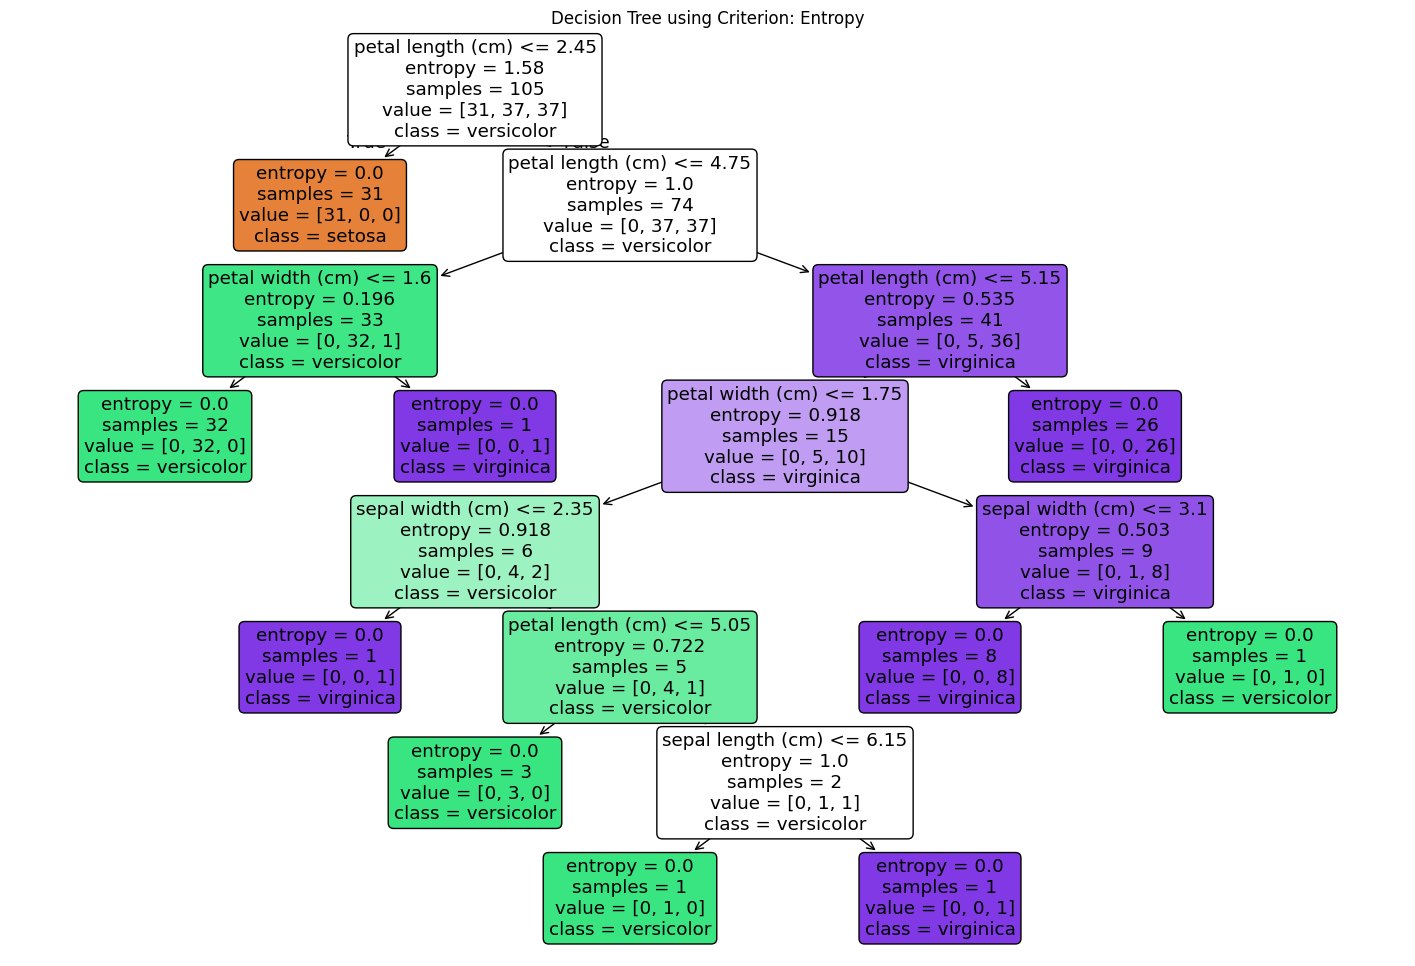

In [ ]:
# Cell 4: Train and Visualize with 'entropy' criterion
print("--- Training and Visualizing with 'entropy' criterion ---")
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)

# Performance Measures
y_pred_entropy = clf_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
depth_entropy = clf_entropy.get_depth()

print(f"Accuracy (entropy): {accuracy_entropy:.4f}")
print(f"Tree Depth (entropy): {depth_entropy}")

# Visualize the tree
plt.figure(figsize=(18, 12))
plot_tree(clf_entropy, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title("Decision Tree using Criterion: Entropy")
plt.show()

GINI CRITERION

--- Training and Visualizing with 'gini' criterion ---
Accuracy (gini): 1.0000
Tree Depth (gini): 6


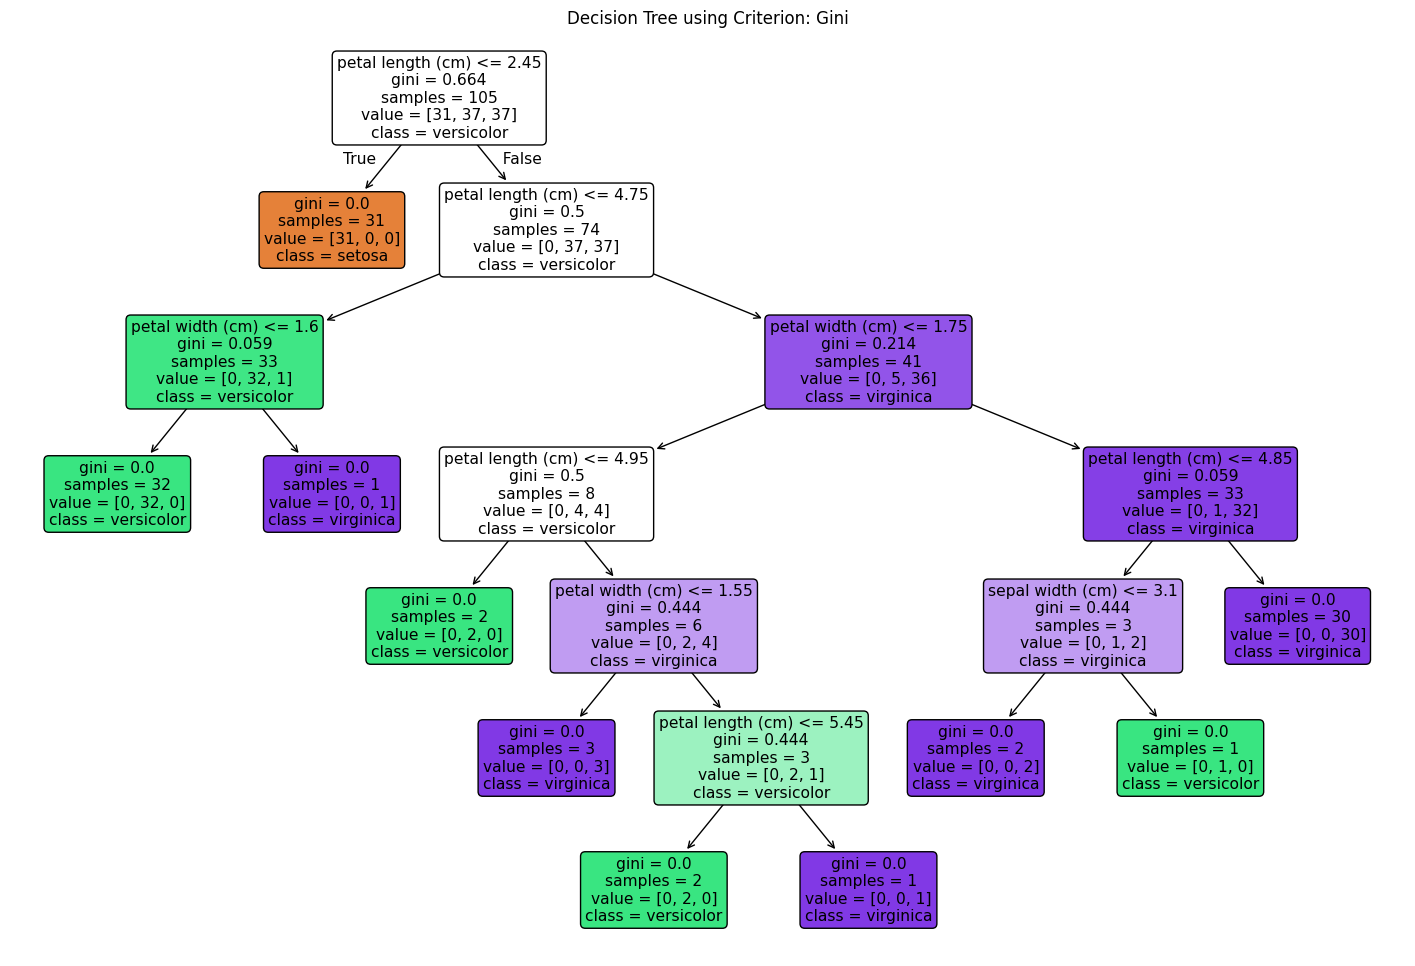

In [ ]:
# Cell 5: Training and Visualizing with 'gini' criterion
print("--- Training and Visualizing with 'gini' criterion ---")
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)

# Performance Measures
y_pred_gini = clf_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)
depth_gini = clf_gini.get_depth()

print(f"Accuracy (gini): {accuracy_gini:.4f}")
print(f"Tree Depth (gini): {depth_gini}")

# Visualize the tree
plt.figure(figsize=(18, 12))
plot_tree(clf_gini, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title("Decision Tree using Criterion: Gini")
plt.show()

COMPARE

In [ ]:
# Cell 6: Final Comparison of Initial Models
print("--- Final Comparison of Initial Models ---")
print(f"Entropy Model -> Accuracy: {accuracy_entropy:.4f}, Depth: {depth_entropy}")
print(f"Gini Model    -> Accuracy: {accuracy_gini:.4f}, Depth: {depth_gini}")

--- Final Comparison of Initial Models ---
Entropy Model -> Accuracy: 0.9778, Depth: 7
Gini Model    -> Accuracy: 1.0000, Depth: 6


Find the Optimal ccp_alpha for Post-Pruning

--- Finding the optimal ccp_alpha for Post-Pruning ---
Number of alphas to test: 7
Alpha values tested:
 [0.         0.00923521 0.01269841 0.01269841 0.01847042 0.02705804
 0.25028684]

The best ccp_alpha value is: 0.000000
This value was chosen because it resulted in the highest accuracy on the unseen test data,
representing the best trade-off between model simplicity and predictive power.


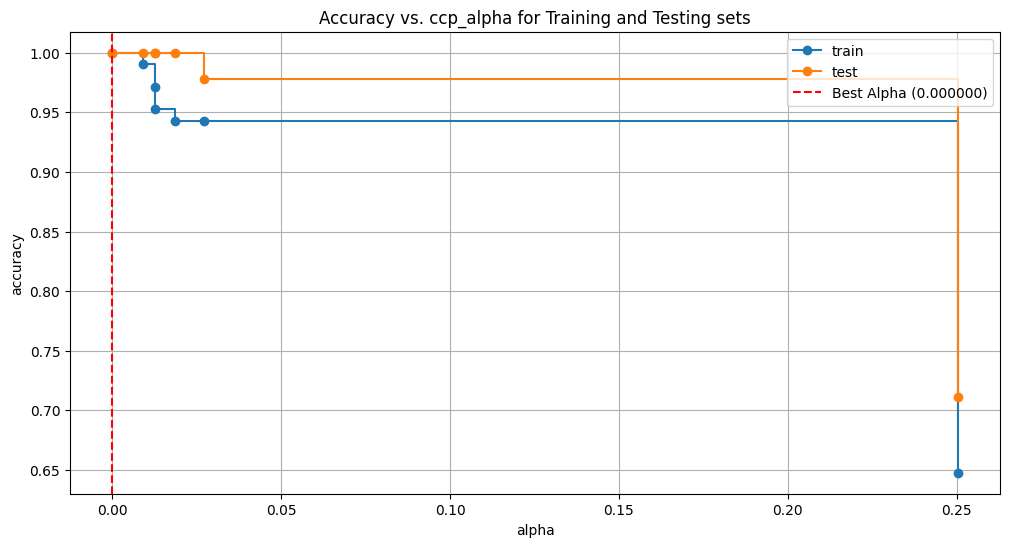

In [ ]:
# Cell 7: Find the optimal ccp_alpha for Post-Pruning
print("--- Finding the optimal ccp_alpha for Post-Pruning ---")
path = clf_gini.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# We exclude the maximum alpha as it prunes the tree to just a root node.
ccp_alphas = ccp_alphas[:-1]

clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Calculate accuracy on training and testing sets for each alpha
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

# Find the alpha that maximizes the test score
best_alpha_index = np.argmax(test_scores)
best_ccp_alpha = ccp_alphas[best_alpha_index]

print(f"Number of alphas to test: {len(ccp_alphas)}")
print("Alpha values tested:\n", ccp_alphas)
print(f"\nThe best ccp_alpha value is: {best_ccp_alpha:.6f}")
print("This value was chosen because it resulted in the highest accuracy on the unseen test data,")
print("representing the best trade-off between model simplicity and predictive power.")


# Plot accuracy vs alpha
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs. ccp_alpha for Training and Testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test", drawstyle="steps-post")
ax.axvline(best_ccp_alpha, linestyle='--', color='red', label=f'Best Alpha ({best_ccp_alpha:.6f})')
ax.legend()
plt.grid()
plt.show()

PLOT DIFFERENT CCPAPLHA

--- Visualizing Trees for Manually Selected ccp_alpha Values ---

--- Results for ccp_alpha = 0.0000 ---
 -> Tree Depth: 6
 -> Test Accuracy: 1.0000


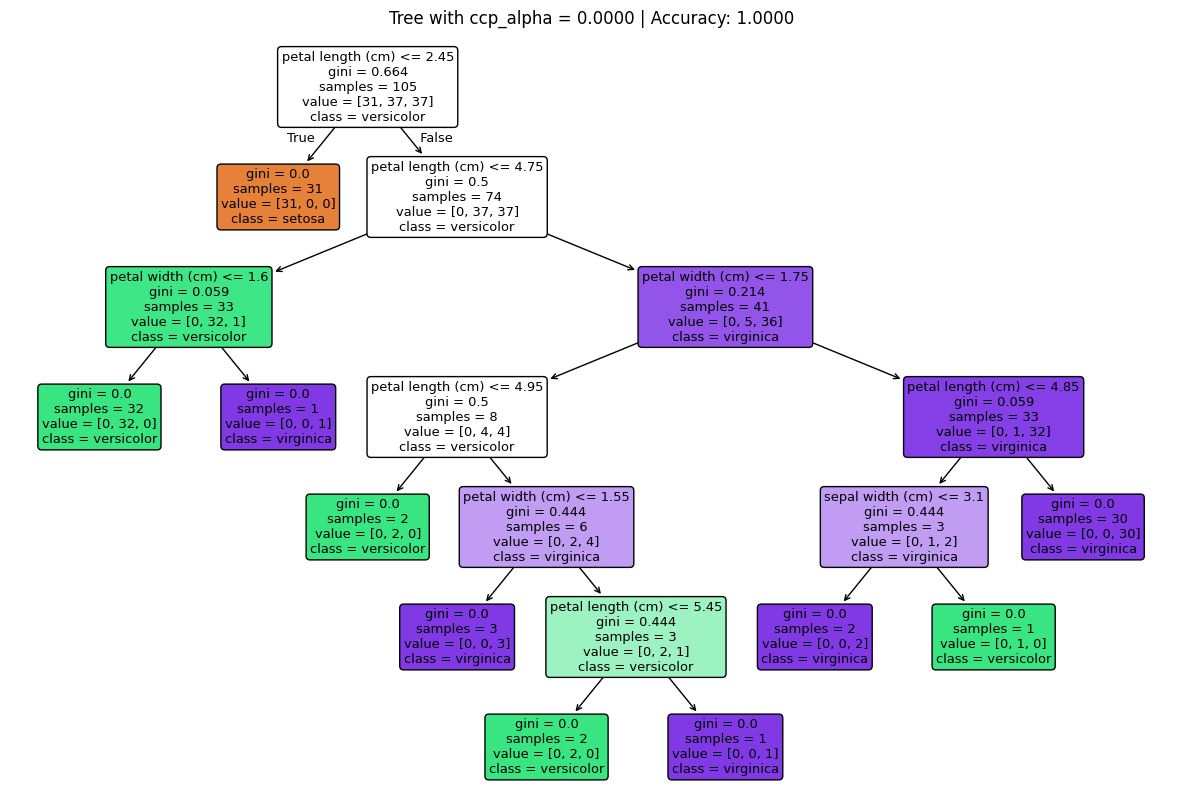


--- Results for ccp_alpha = 0.0500 ---
 -> Tree Depth: 2
 -> Test Accuracy: 0.9778


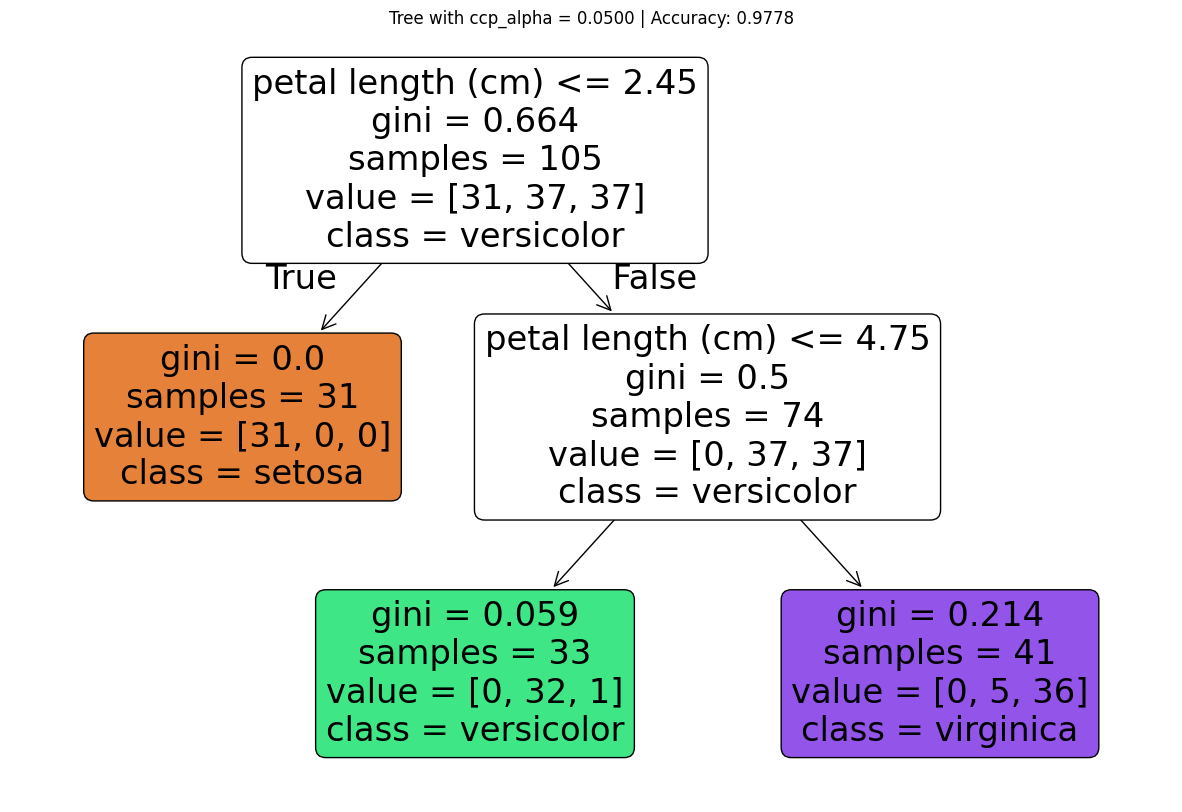


--- Results for ccp_alpha = 0.0327 ---
 -> Tree Depth: 2
 -> Test Accuracy: 0.9778


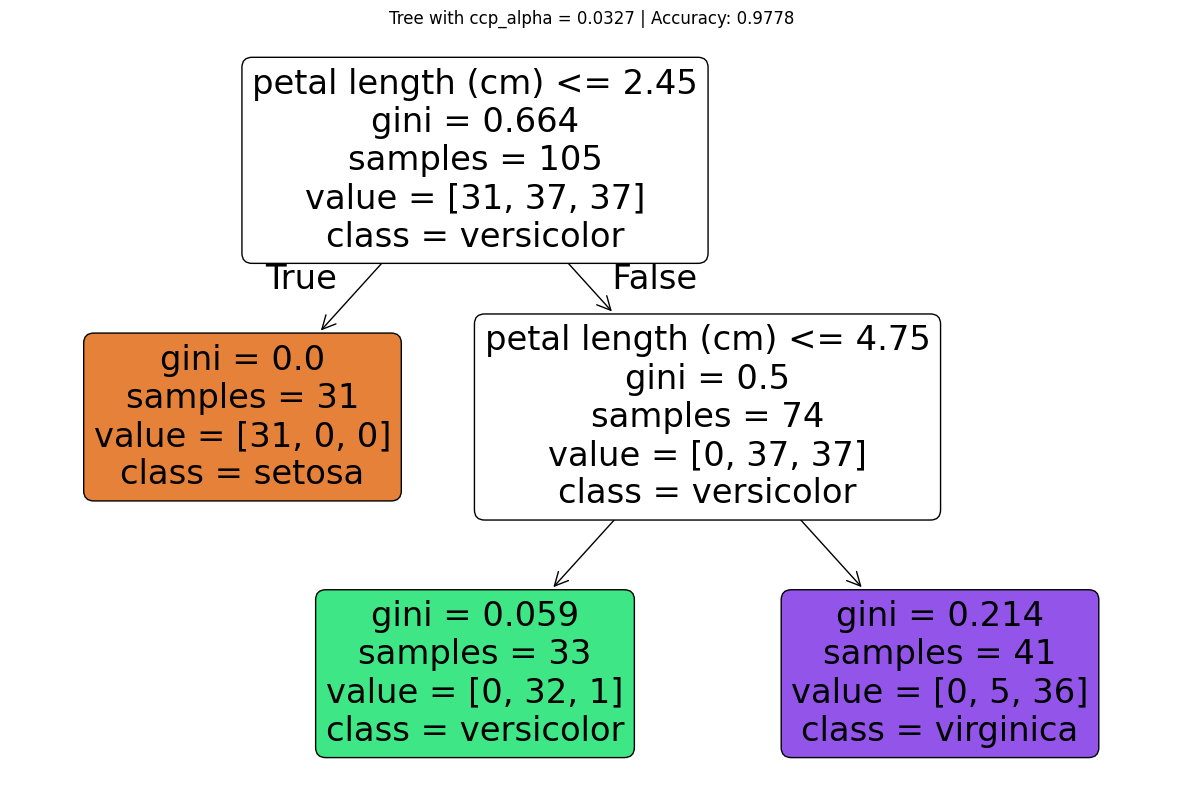

In [ ]:
# Cell 8: Visualize Trees for Specific ccp_alpha Values (0.0000 and 0.05)
print("--- Visualizing Trees for Manually Selected ccp_alpha Values ---")

# The specific alpha values you requested to compare
alphas_to_plot = [0.0000, 0.05,0.0327]

for alpha_val in alphas_to_plot:
    # Create and train a model for the specific alpha
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha_val)
    clf.fit(X_train, y_train)

    # Calculate performance metrics for this tree
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    depth = clf.get_depth()

    print(f"\n--- Results for ccp_alpha = {alpha_val:.4f} ---")
    print(f" -> Tree Depth: {depth}")
    print(f" -> Test Accuracy: {accuracy:.4f}")

    # Plot the tree
    plt.figure(figsize=(15, 10))
    plot_tree(clf,
              filled=True,
              feature_names=iris.feature_names,
              class_names=iris.target_names,
              rounded=True)
    plt.title(f"Tree with ccp_alpha = {alpha_val:.4f} | Accuracy: {accuracy:.4f}")
    plt.show()

--- Training and Visualizing the Final, Optimal Pruned Tree ---
Performance of the Post-Pruned Gini Tree:
Best ccp_alpha: 0.000000
Accuracy (pruned): 1.0000
Tree Depth (pruned): 6


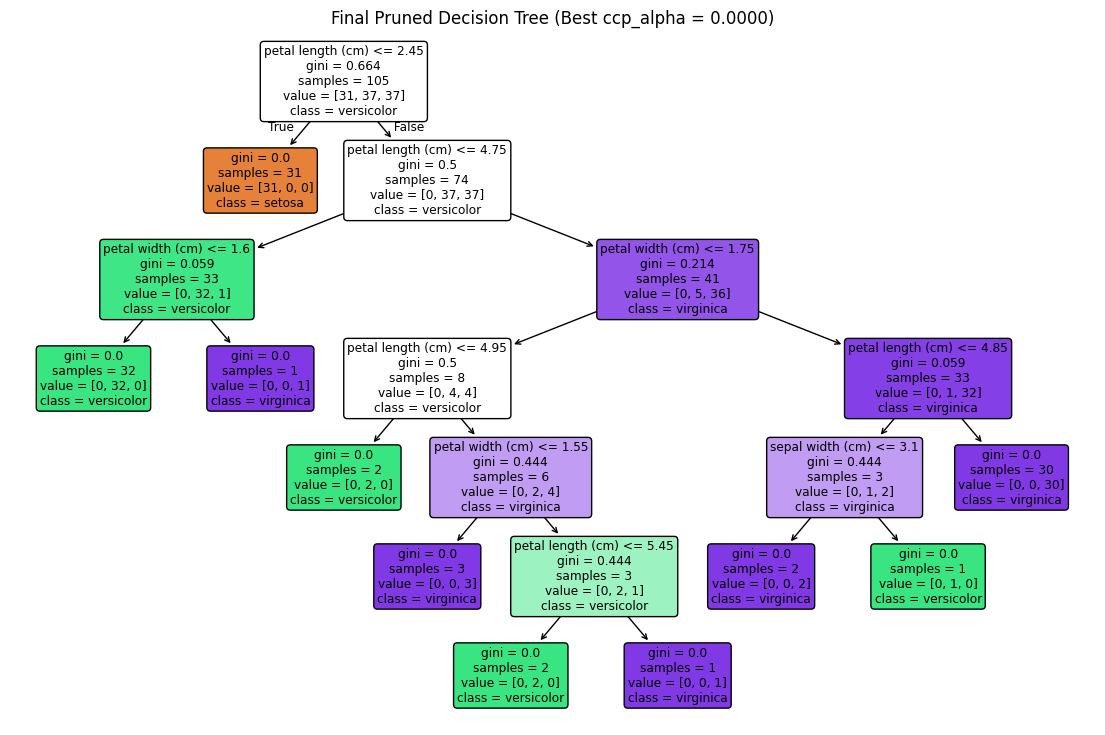

In [ ]:
# Cell 9: Train and Visualize the Final Pruned Tree
print("--- Training and Visualizing the Final, Optimal Pruned Tree ---")

# Create the final model with the best ccp_alpha value
clf_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
clf_pruned.fit(X_train, y_train)

# Evaluate the pruned model
y_pred_pruned = clf_pruned.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
depth_pruned = clf_pruned.get_depth()

print("Performance of the Post-Pruned Gini Tree:")
print(f"Best ccp_alpha: {best_ccp_alpha:.6f}")
print(f"Accuracy (pruned): {accuracy_pruned:.4f}")
print(f"Tree Depth (pruned): {depth_pruned}")

# Visualize the final pruned tree
plt.figure(figsize=(14, 9))
plot_tree(clf_pruned, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title(f"Final Pruned Decision Tree (Best ccp_alpha = {best_ccp_alpha:.4f})")
plt.show()